In [6]:
from data_loader import daily_data_loader
df = daily_data_loader()

print(f'Available Features:')
print(df.columns.to_list())

Available Features:
['date', 'kwh', 'temp_mean', 'temp_min', 'temp_max', 'rhum_mean', 'rhum_min', 'rhum_max', 'prcp_sum', 'wspd_mean', 'wspd_min', 'wspd_max', 'pres_mean', 'wdir_mean', 'dayofweek', 'month', 'is_weekend', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'wdir_mean_sin', 'wdir_mean_cos']


In [7]:
FEATURE_COLS = [
    'temp_mean', 
    'temp_min',
    'temp_max', 
    'rhum_mean', 
    'rhum_min', 
    'rhum_max', 
    'prcp_sum', 
    'wspd_mean', 
    'wspd_min', 
    'wspd_max', 
    'pres_mean', 
    'is_weekend', 
    'dayofweek_sin', 'dayofweek_cos', 
    'month_sin', 'month_cos', 
    'wdir_mean_sin', 'wdir_mean_cos'
]

TARGET_COL   = "kwh"

In [8]:
from sklearn.preprocessing import StandardScaler

# Sequential separation to prevent data leakage
X_data = df[FEATURE_COLS].values
y_data = df[TARGET_COL].values.reshape(-1, 1)  # Reshape required for scaling

split_idx = int(len(X_data) * 0.75)

scaler_X = StandardScaler()
scaler_X.fit(X_data[:split_idx])          # Learn the math from the past
X_scaled = scaler_X.transform(X_data)     # Apply the math to the whole timeline

scaler_y = StandardScaler()
scaler_y.fit(y_data[:split_idx])
y_scaled = scaler_y.transform(y_data)

X_train = X_scaled[:split_idx]
X_test  = X_scaled[split_idx:]
y_train = y_scaled[:split_idx]
y_test  = y_scaled[split_idx:]

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}  (mean={y_train.mean():.3f} kWh, std={y_train.std():.3f})")
print(f"y_test  shape: {y_test.shape}  (mean={y_test.mean():.3f} kWh, std={y_test.std():.3f})")

Features:      ['temp_mean', 'temp_min', 'temp_max', 'rhum_mean', 'rhum_min', 'rhum_max', 'prcp_sum', 'wspd_mean', 'wspd_min', 'wspd_max', 'pres_mean', 'is_weekend', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'wdir_mean_sin', 'wdir_mean_cos']
X_train shape: (1161, 18)
X_test shape:  (388, 18)
y_train shape: (1161, 1)  (mean=0.000 kWh, std=1.000)
y_test  shape: (388, 1)  (mean=0.320 kWh, std=1.057)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

pred_scaled = model.predict(X_test)
pred_kwh = scaler_y.inverse_transform(pred_scaled)
test_kwh = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(test_kwh, pred_kwh))
r2   = r2_score(test_kwh, pred_kwh)
mae = mean_absolute_error(test_kwh, pred_kwh)

print(f"Linear Regression | R²={r2:.3f}  RMSE={rmse:.4f} kWh  MAE={mae:.4f} kWh")

# Coefficients
print(f'Coefficients:')
for i, coeff in enumerate(model.coef_[0]):
    print(f'{FEATURE_COLS[i]}: {coeff:0.3f}')

Linear Regression | R²=0.678  RMSE=13.5923 kWh  MAE=10.0393 kWh
Coefficients:
temp_mean: -0.645
temp_min: -0.141
temp_max: -0.034
rhum_mean: -0.068
rhum_min: 0.036
rhum_max: -0.049
prcp_sum: 0.045
wspd_mean: -0.066
wspd_min: 0.050
wspd_max: 0.012
pres_mean: -0.046
is_weekend: 0.028
dayofweek_sin: 0.007
dayofweek_cos: 0.044
month_sin: -0.025
month_cos: 0.016
wdir_mean_sin: 0.055
wdir_mean_cos: -0.018


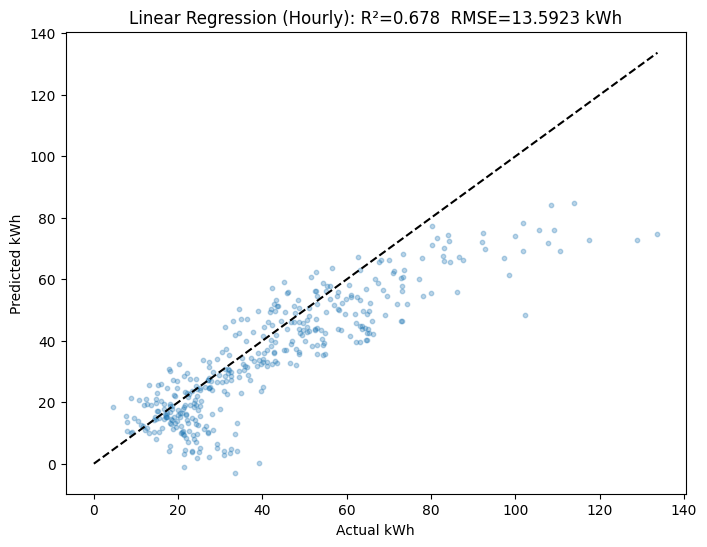

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(test_kwh, pred_kwh, alpha=0.3, s=10)
plt.plot([0, test_kwh.max()], [0, test_kwh.max()], 'k--')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title(f'Linear Regression (Hourly): R²={r2:.3f}  RMSE={rmse:.4f} kWh')
plt.show()

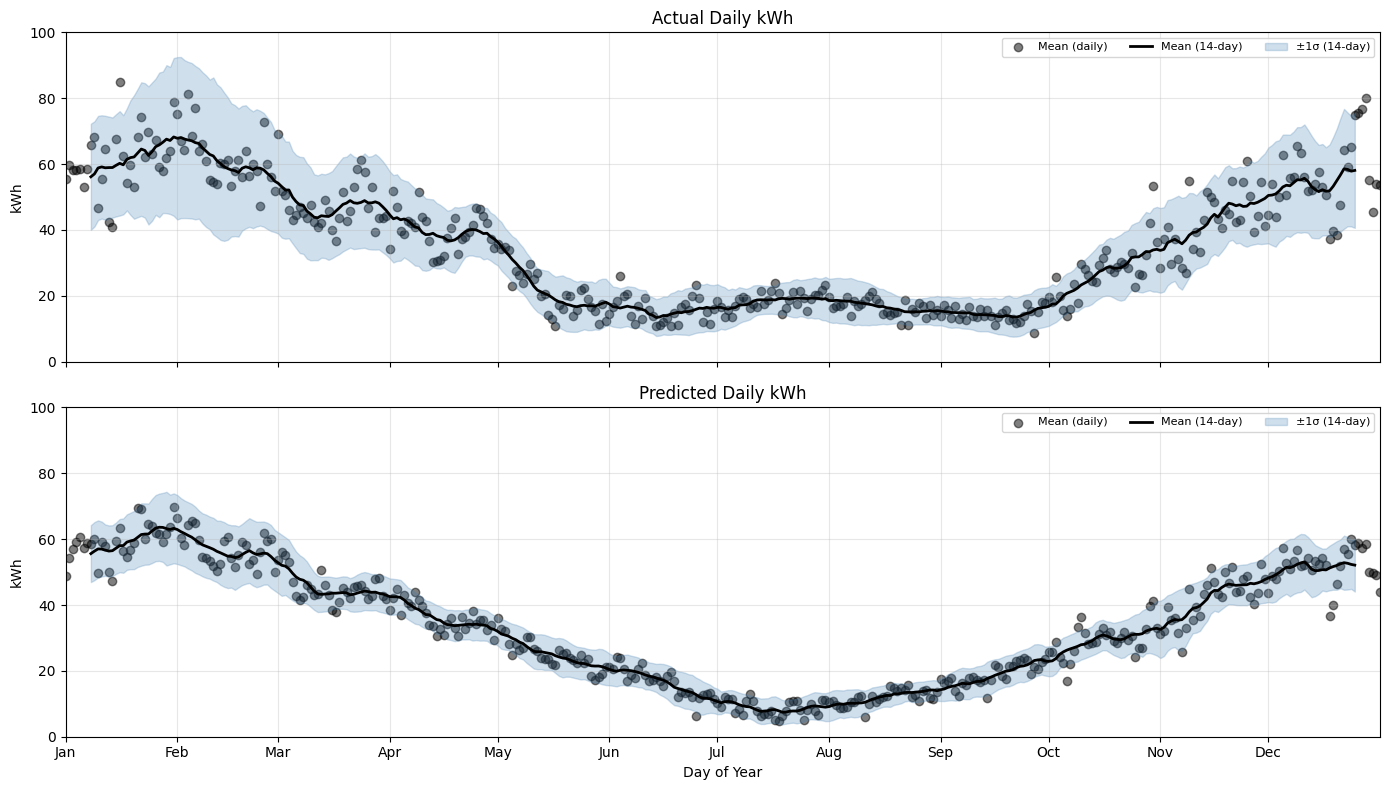

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import calendar
import numpy as np
import torch

# --- Generate predictions ---
with torch.no_grad():
    all_preds_scaled = model.predict(X_scaled)
all_preds_kwh = scaler_y.inverse_transform(all_preds_scaled).flatten()

# --- Collect per-year traces into a (366, n_years) grid ---
years = sorted(df["date"].dt.year.unique())

def build_doy_matrix(values):
    """Stack each year's daily values into columns aligned by day-of-year."""
    matrix = np.full((366, len(years)), np.nan)
    for i, yr in enumerate(years):
        mask = df["date"].dt.year == yr
        doy = df.loc[mask, "date"].dt.dayofyear.values - 1  # 0-indexed
        matrix[doy, i] = values[mask]
    return matrix

actual_matrix = build_doy_matrix(df[TARGET_COL].values)
pred_matrix   = build_doy_matrix(all_preds_kwh)

doy_axis = np.arange(1, 367)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, matrix, title in [(ax1, actual_matrix, "Actual Daily kWh"),
                           (ax2, pred_matrix,   "Predicted Daily kWh")]:
    mean = np.nanmean(matrix, axis=1)
    std  = np.nanstd(matrix, axis=1)

    # # Faint individual year lines
    # cmap = plt.cm.viridis
    # for i, yr in enumerate(years):
    #     ax.plot(doy_axis, matrix[:, i], color=cmap(i / max(len(years)-1, 1)),
    #             linewidth=0.6, alpha=0.3, label=str(yr))

    # n-day moving average
    n_days = 14
    half = n_days // 2
    mean_smooth = np.convolve(mean, np.ones(n_days)/n_days, mode='same')

    # Chop edges where convolution doesn't have full window
    doy_smooth = doy_axis[half:-half]
    mean_smooth = mean_smooth[half:-half]

    ax.scatter(doy_axis, mean, color="black", alpha=0.5, label="Mean (daily)")
    ax.plot(doy_smooth, mean_smooth, color="black", linewidth=2, label=f"Mean ({n_days}-day)")
    
    std_smooth  = np.convolve(std, np.ones(n_days)/n_days, mode='same')
    std_smooth = std_smooth[half:-half]
    
    ax.fill_between(doy_smooth, mean_smooth - std_smooth, mean_smooth + std_smooth,
                    color="steelblue", alpha=0.25, label=f"±1σ ({n_days}-day)")

    ax.set_ylabel("kWh")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8, ncol=min(len(years) + 2, 7))
    ax.grid(True, alpha=0.3)

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = list(calendar.month_abbr[1:])
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mticker.FixedLocator(month_starts))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(month_labels))
    ax.set_xlim(1, 366)
    ax.set_ylim(0,100)

ax2.set_xlabel("Day of Year")
plt.tight_layout()
plt.show()